In [6]:
import os

for item in os.listdir("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce"):
    print(item)

olist_customers_dataset.csv
olist_sellers_dataset.csv
olist_order_reviews_dataset.csv
olist_order_items_dataset.csv
olist_products_dataset.csv
olist_geolocation_dataset.csv
product_category_name_translation.csv
olist_orders_dataset.csv
olist_order_payments_dataset.csv


In [7]:
!pip install pyspark -q

In [8]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EcommerceETL") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark session created successfully")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/27 16:43:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark session created successfully


In [9]:
RAW_PATH = "/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce"

orders = spark.read.csv(f"{RAW_PATH}/olist_orders_dataset.csv",
                        header=True, inferSchema=True)
customers = spark.read.csv(f"{RAW_PATH}/olist_customers_dataset.csv",
                           header=True, inferSchema=True)
payments = spark.read.csv(f"{RAW_PATH}/olist_order_payments_dataset.csv",
                          header=True, inferSchema=True)
items = spark.read.csv(f"{RAW_PATH}/olist_order_items_dataset.csv",
                       header=True, inferSchema=True)

print("--- Ingestion Summary ---")
print(f"Orders:    {orders.count()} rows")
print(f"Customers: {customers.count()} rows")
print(f"Payments:  {payments.count()} rows")
print(f"Items:     {items.count()} rows")

--- Ingestion Summary ---
Orders:    99441 rows
Customers: 99441 rows
Payments:  103886 rows
Items:     112650 rows


In [10]:
from pyspark.sql import functions as F

def clean_orders(df):
    rows_before = df.count()
    df = df.dropna(subset=["order_id", "customer_id", "order_status"])
    df = df.dropDuplicates(["order_id"])
    df = df.filter(F.col("order_status") == "delivered")
    rows_after = df.count()
    print(f"  Orders:    {rows_before} -> {rows_after} rows ({rows_before - rows_after} removed)")
    return df

def clean_customers(df):
    rows_before = df.count()
    df = df.dropna(subset=["customer_id", "customer_state"])
    df = df.dropDuplicates(["customer_id"])
    rows_after = df.count()
    print(f"  Customers: {rows_before} -> {rows_after} rows ({rows_before - rows_after} removed)")
    return df

def clean_payments(df):
    rows_before = df.count()
    df = df.dropna(subset=["order_id", "payment_value"])
    df = df.filter(F.col("payment_value") > 0)
    rows_after = df.count()
    print(f"  Payments:  {rows_before} -> {rows_after} rows ({rows_before - rows_after} removed)")
    return df

def clean_items(df):
    rows_before = df.count()
    df = df.dropna(subset=["order_id", "product_id", "price"])
    df = df.filter(F.col("price") > 0)
    rows_after = df.count()
    print(f"  Items:     {rows_before} -> {rows_after} rows ({rows_before - rows_after} removed)")
    return df

print("--- Cleaning Summary ---")
orders    = clean_orders(orders)
customers = clean_customers(customers)
payments  = clean_payments(payments)
items     = clean_items(items)
print("--- Cleaning Complete ---")

--- Cleaning Summary ---


  Orders:    99441 -> 96478 rows (2963 removed)


  Customers: 99441 -> 99441 rows (0 removed)
  Payments:  103886 -> 103877 rows (9 removed)
  Items:     112650 -> 112650 rows (0 removed)
--- Cleaning Complete ---


In [11]:
def aggregate_payments(df):
    return df.groupBy("order_id").agg(
        F.sum("payment_value").alias("total_payment"),
        F.count("payment_sequential").alias("payment_count"),
        F.first("payment_type").alias("primary_payment_type")
    )

def aggregate_items(df):
    return df.groupBy("order_id").agg(
        F.sum("price").alias("items_subtotal"),
        F.sum("freight_value").alias("total_freight"),
        F.count("order_item_id").alias("item_count")
    )

payments_agg = aggregate_payments(payments)
items_agg    = aggregate_items(items)

master = orders \
    .join(customers, "customer_id", "left") \
    .join(payments_agg, "order_id", "left") \
    .join(items_agg, "order_id", "left")

master = master.cache()
master = master.repartition(8)

master = master \
    .withColumn("delivery_time_days",
        F.datediff(F.col("order_delivered_customer_date"),
                   F.col("order_purchase_timestamp"))) \
    .withColumn("delivery_delay_days",
        F.datediff(F.col("order_delivered_customer_date"),
                   F.col("order_estimated_delivery_date"))) \
    .withColumn("was_late",
        F.when(F.col("delivery_delay_days") > 0, True).otherwise(False)) \
    .withColumn("order_value_bucket",
        F.when(F.col("total_payment") < 50,  "low")
         .when(F.col("total_payment") < 200, "medium")
         .when(F.col("total_payment") < 500, "high")
         .otherwise("premium")) \
    .withColumn("purchase_year",  F.year("order_purchase_timestamp")) \
    .withColumn("purchase_month", F.month("order_purchase_timestamp"))

print("--- Transformation Summary ---")
print(f"  Master table rows: {master.count()}")
print(f"  Master table cols: {len(master.columns)}")
print("--- Transformation Complete ---")

--- Transformation Summary ---


  Master table rows: 96478
  Master table cols: 24
--- Transformation Complete ---


In [12]:
print("--- Aggregations ---")

print("\n  Top 5 states by revenue:")
master.groupBy("customer_state").agg(
    F.round(F.sum("total_payment"), 2).alias("total_revenue"),
    F.count("order_id").alias("order_count"),
    F.round(F.avg("total_payment"), 2).alias("avg_order_value")
).orderBy("total_revenue", ascending=False).show(5)

print("  Monthly sales trend (first 5 months):")
master.groupBy("purchase_year", "purchase_month").agg(
    F.round(F.sum("total_payment"), 2).alias("monthly_revenue"),
    F.count("order_id").alias("order_count")
).orderBy("purchase_year", "purchase_month").show(5)

print("  Delivery performance (fastest 5 states):")
master.filter(F.col("delivery_time_days").isNotNull()) \
    .groupBy("customer_state").agg(
        F.round(F.avg("delivery_time_days"), 1).alias("avg_delivery_days"),
        F.round(F.avg("delivery_delay_days"), 1).alias("avg_delay_days"),
        F.round(
            F.sum(F.col("was_late").cast("int")) /
            F.count("order_id") * 100, 1
        ).alias("late_delivery_pct")
    ).orderBy("avg_delivery_days").show(5)

print("  Order value distribution:")
master.groupBy("order_value_bucket").agg(
    F.count("order_id").alias("order_count"),
    F.round(F.sum("total_payment"), 2).alias("total_revenue"),
    F.round(F.avg("total_payment"), 2).alias("avg_value")
).orderBy("avg_value").show()

print("--- Pipeline Complete ---")

--- Aggregations ---

  Top 5 states by revenue:
+--------------+-------------+-----------+---------------+
|customer_state|total_revenue|order_count|avg_order_value|
+--------------+-------------+-----------+---------------+
|            SP|   5770266.19|      40501|         142.48|
|            RJ|   2055690.45|      12350|         166.45|
|            MG|   1819277.61|      11354|         160.23|
|            RS|     861802.4|       5345|         161.24|
|            PR|    781919.55|       4923|         158.83|
+--------------+-------------+-----------+---------------+
only showing top 5 rows
  Monthly sales trend (first 5 months):
+-------------+--------------+---------------+-----------+
|purchase_year|purchase_month|monthly_revenue|order_count|
+-------------+--------------+---------------+-----------+
|         2016|             9|           NULL|          1|
|         2016|            10|       46566.71|        265|
|         2016|            12|          19.62|          1|
| 

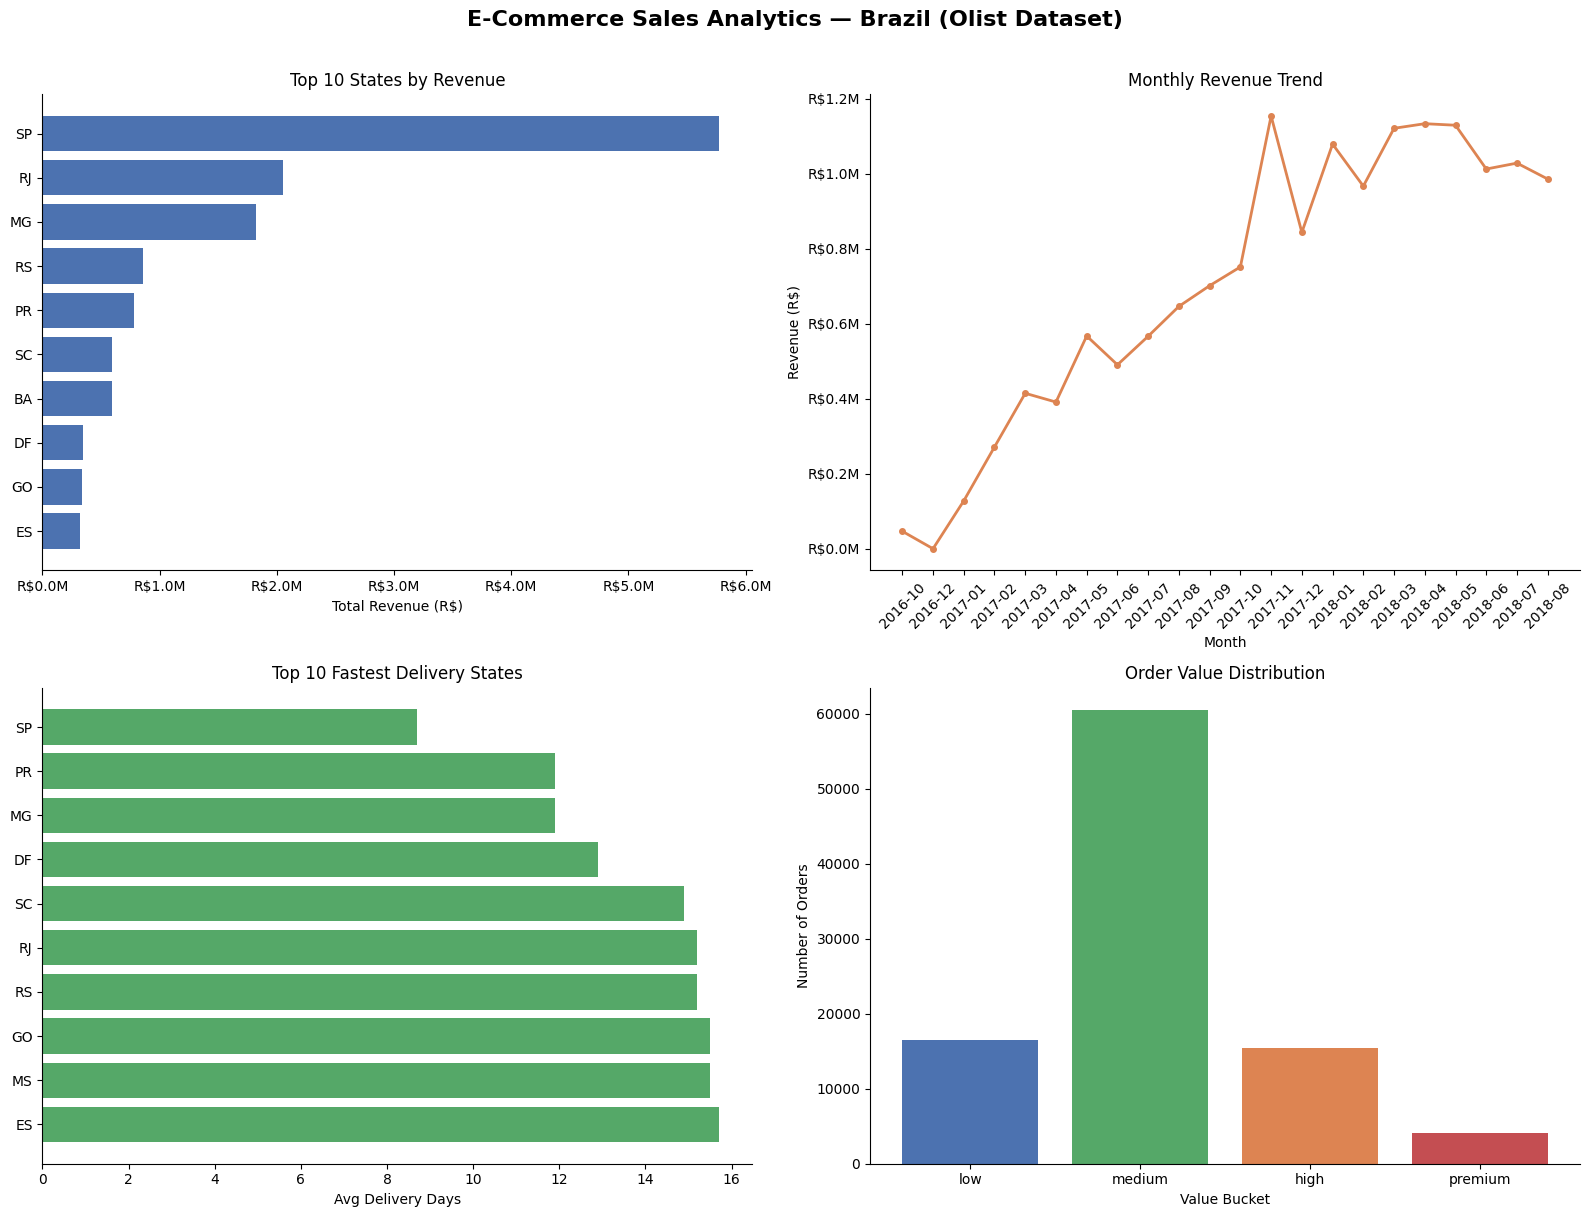

Visualisations complete


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

rev_state_pd = master.groupBy("customer_state").agg(
    F.round(F.sum("total_payment"), 2).alias("total_revenue"),
    F.count("order_id").alias("order_count")
).orderBy("total_revenue", ascending=False).limit(10).toPandas()

monthly_pd = master.groupBy("purchase_year", "purchase_month").agg(
    F.round(F.sum("total_payment"), 2).alias("monthly_revenue"),
    F.count("order_id").alias("order_count")
).orderBy("purchase_year", "purchase_month").toPandas()
monthly_pd["period"] = monthly_pd["purchase_year"].astype(str) + "-" + \
                       monthly_pd["purchase_month"].astype(str).str.zfill(2)
monthly_pd = monthly_pd.dropna(subset=["monthly_revenue"])

delivery_pd = master.filter(F.col("delivery_time_days").isNotNull()) \
    .groupBy("customer_state").agg(
        F.round(F.avg("delivery_time_days"), 1).alias("avg_delivery_days")
    ).orderBy("avg_delivery_days").limit(10).toPandas()

buckets_pd = master.groupBy("order_value_bucket").agg(
    F.count("order_id").alias("order_count")
).toPandas()
bucket_order = ["low", "medium", "high", "premium"]
buckets_pd["order_value_bucket"] = pd.Categorical(
    buckets_pd["order_value_bucket"], categories=bucket_order, ordered=True
)
buckets_pd = buckets_pd.sort_values("order_value_bucket")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("E-Commerce Sales Analytics — Brazil (Olist Dataset)",
             fontsize=16, fontweight="bold", y=1.01)

# Chart 1 — Revenue by state
axes[0, 0].barh(rev_state_pd["customer_state"][::-1],
                rev_state_pd["total_revenue"][::-1],
                color="#4C72B0")
axes[0, 0].set_title("Top 10 States by Revenue")
axes[0, 0].set_xlabel("Total Revenue (R$)")
axes[0, 0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))

# Chart 2 — Monthly sales trend
axes[0, 1].plot(monthly_pd["period"], monthly_pd["monthly_revenue"],
                color="#DD8452", linewidth=2, marker="o", markersize=4)
axes[0, 1].set_title("Monthly Revenue Trend")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Revenue (R$)")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))

# Chart 3 — Avg delivery days by state
axes[1, 0].barh(delivery_pd["customer_state"][::-1],
                delivery_pd["avg_delivery_days"][::-1],
                color="#55A868")
axes[1, 0].set_title("Top 10 Fastest Delivery States")
axes[1, 0].set_xlabel("Avg Delivery Days")

# Chart 4 — Order value distribution
axes[1, 1].bar(buckets_pd["order_value_bucket"],
               buckets_pd["order_count"],
               color=["#4C72B0", "#55A868", "#DD8452", "#C44E52"])
axes[1, 1].set_title("Order Value Distribution")
axes[1, 1].set_xlabel("Value Bucket")
axes[1, 1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.savefig("ecommerce_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualisations complete")